# Exploratory Data Analysis

## Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df = pd.read_csv("../data/processed/processed_superstore.csv")

## Sales/Profit Analysis


### Business Questions

- What has been the common trend for sales throughout years?
- Are sales increasing with time?
- Which months have shown high profitability?

### Aggregating Data

In [6]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = df.groupby("month_year")["sales"].sum()
monthly_profit = df.groupby("month_year")["profit"].sum()

### Visualization

#### Sales Trends over time

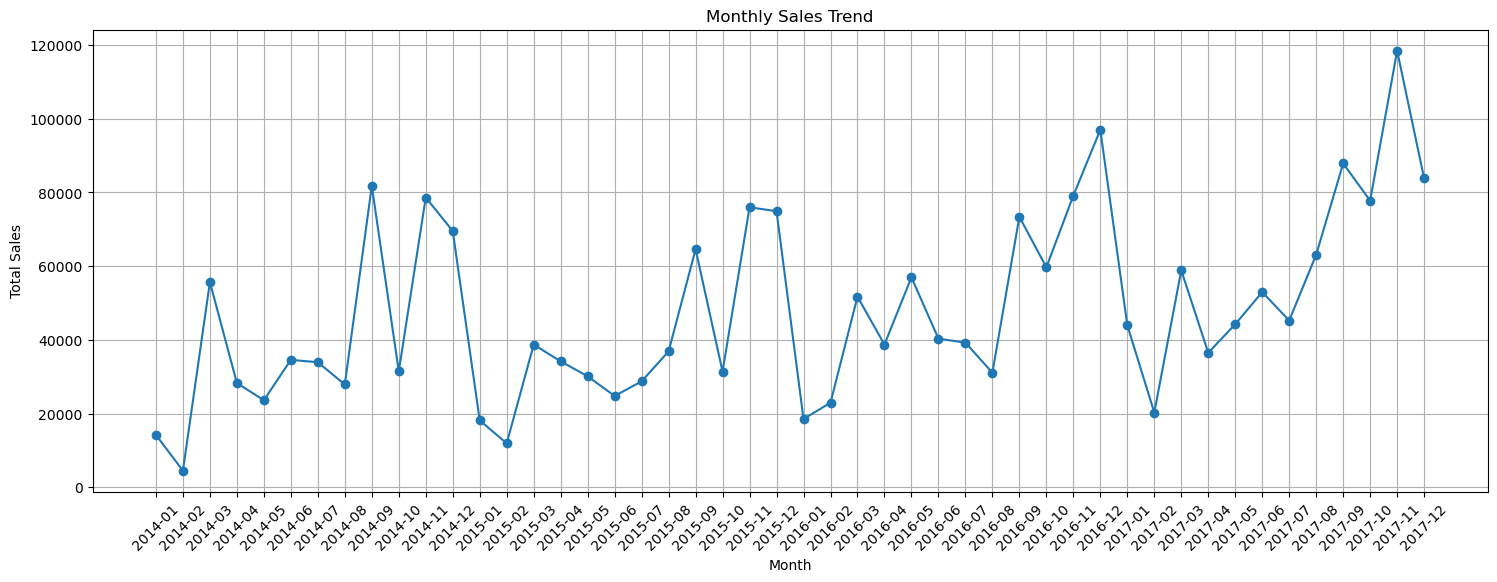

In [7]:
plt.figure(figsize = (18,6))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker = "o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig("../visuals/sales_profit_analysis/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

#### Profit Trends Over Time

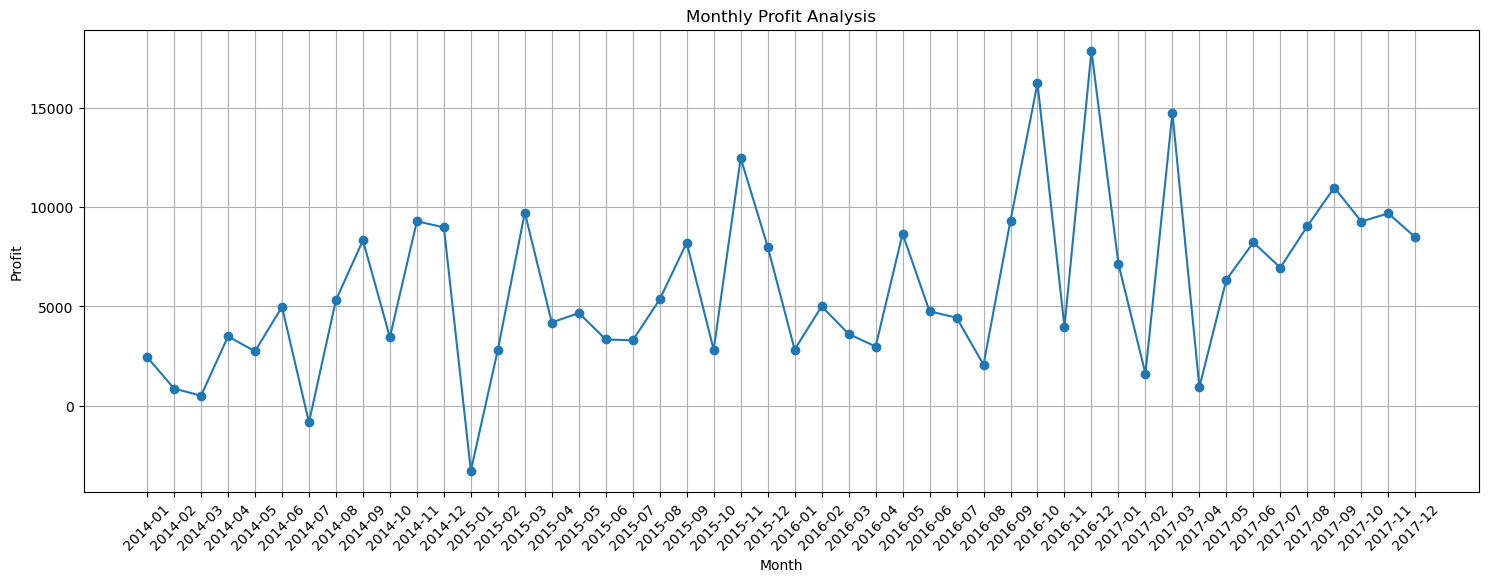

In [8]:
plt.figure(figsize = (18, 6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker = "o"
)

plt.title("Monthly Profit Analysis")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation = 45)
plt.grid(True)

plt.savefig("../visuals/sales_profit_analysis/monthly_profits_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observations and Insights

Sales trends show significant seasonal behavior as follows- 
- Spikes coming in near the end of the year 
- Lows during the initial months of the year.

Year end spikes may be caused by- 
- Holiday season purchases by consumers
- Clearance sale discounts given by the companies.
- Businesses finalizing spending on supplies during the end of the year, hence the increase in B2B purchases.

Initial months of the year show lower sales, probably due to the recovery period after heavy year end sales from both consumers and businesses.

Sales have shown an increase over time, especially during the second half of 2017 when compared to 2014 or 2015.

The last quarter of every year has shown higher profitability as compared to the rest of the year.
The peak is seen during the December month of 2016.

## Product Analysis

### Business Questions

- Which are the highest selling products?
- Which products yield losses despite high sales?
- Which category of products has the highest share in sales?

### Aggregating Data

In [9]:
high_sales_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(5)

# high_sales_no_profit_products
products = df.groupby("product_name").agg({
    "sales": "sum",
    "profit": "sum"
}).sort_values(by="sales", ascending=False)

high_sales_no_profit_products = products[(products["profit"] < 0) & (products["sales"] > 10000)].head(5)

# category wise analysis
category_wise = df.groupby("segment")["sales"].sum()


### Visualization

#### Top 5 High Selling Products

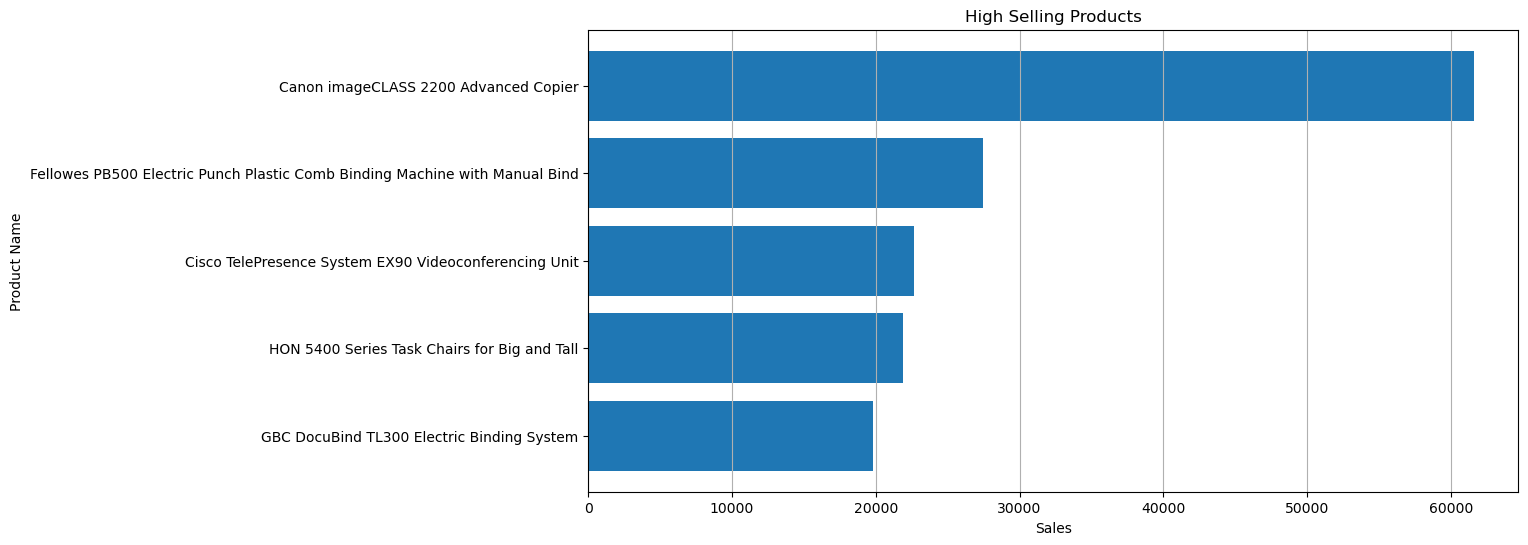

In [10]:
plt.figure(figsize=(12, 6))

plt.barh(
    high_sales_products.index,
    high_sales_products.values,
)

plt.gca().invert_yaxis()
plt.title("High Selling Products")
plt.ylabel("Product Name")
plt.xlabel("Sales")
plt.grid(axis="x")

plt.savefig(
    "../visuals/product_analysis/high_selling_products.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

#### Top 5 High Sales No Profit Products

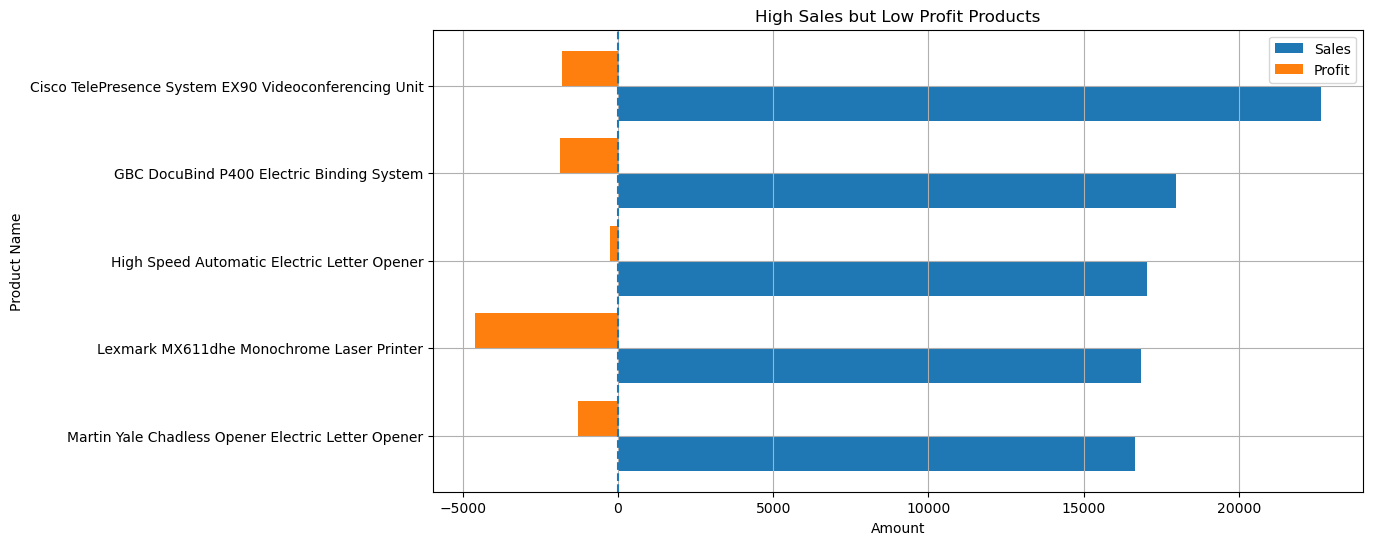

In [11]:
high_sales_no_profit_products = high_sales_no_profit_products.sort_values(
    by="sales",
    ascending=True
)

plt.figure(figsize=(12,6))

bar_width = 0.4

y_positions = np.arange(len(high_sales_no_profit_products))

plt.barh(
    y_positions - bar_width/2,
    high_sales_no_profit_products["sales"],
    height=bar_width,
    label="Sales"
)

plt.barh(
    y_positions + bar_width/2,
    high_sales_no_profit_products["profit"],
    height=bar_width,
    label="Profit"
)

plt.yticks(
    y_positions,
    high_sales_no_profit_products.index
)

plt.axvline(x=0,
            linestyle="--")

plt.title("High Sales but Low Profit Products")
plt.xlabel("Amount")
plt.ylabel("Product Name")
plt.legend()
plt.grid(True)

plt.savefig("../visuals/product_analysis/high_sales_no_profit_products.png",
            dpi = 300,
            bbox_inches = "tight")

plt.show()

#### Category Wise Segmentation

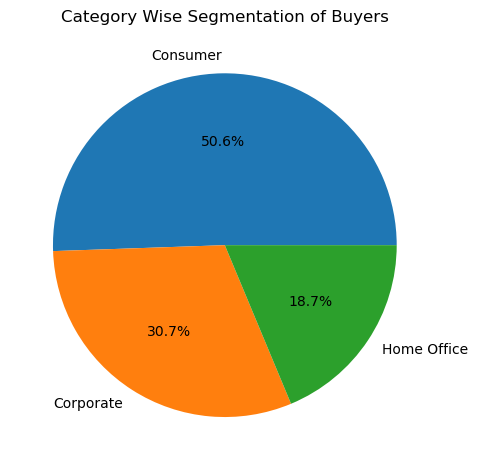

In [12]:
plt.pie(category_wise,
        labels= category_wise.index,
        autopct= "%1.1f%%"
)

plt.title("Category Wise Segmentation of Buyers")

plt.savefig("../visuals/product_analysis/category_wise.png",
            dpi = 300,
            bbox_inches = "tight")

plt.tight_layout()
plt.show()

### Observations and Insights

Products such as 

- Canon copier
- Fellowes binding machine
- Cisco teleconferencing unit

contribute the most to the overall sales of the online store.

Products such as 

- Cisco Teleconferencing Unit
- GBC Electric Binding System
- High Speed Letter Opener

concur losses despite having a high amount of sales. This could be due to

- Inefficient discounting strategies by the store
- Logistics costs reducing profitability

Coming to the category segmentation, we see that 

- The Consumer segment contributes the most to the sales as well as the profits
- The Home Office segment is at the last in both of the fields.
- The store should continue catering well enough to the Consumer segment, while simultaneously improving marketing strategies and sales for the Home Office segment. 

## Geographical Analysis

### Business Questions

- Which city has the highest number of customers?
- Which region brings in the highest revenue?

### Aggregating Data

In [13]:
customers = df.groupby("city")["customer_id"].count().sort_values(ascending=False)
revenue = df.groupby("region")["sales"].sum().sort_values(ascending=False)

### Visualization

#### Top 5 Cities by Number of Customers

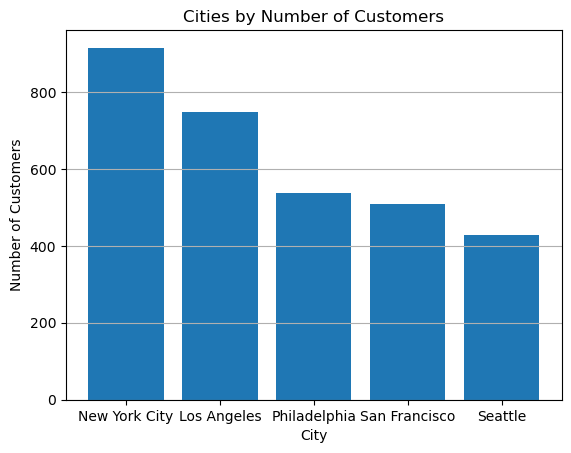

In [14]:
plt.Figure(figsize=(12, 6))

plt.bar(
    customers.head(5).index,
    customers.head(5).values
)

plt.title("Cities by Number of Customers")
plt.ylabel("Number of Customers")
plt.xlabel("City")
plt.grid(axis='y')
plt.savefig("../visuals/geographical_analysis/cities_by_customers",
            dpi = 300,
            bbox_inches = "tight")

plt.show()

#### Regions by Sales

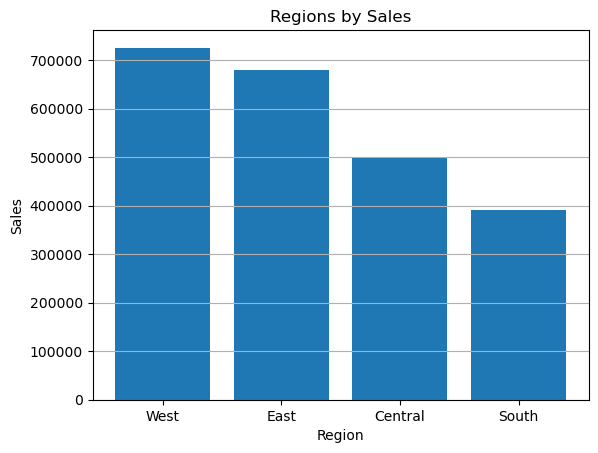

In [15]:
plt.Figure(figsize=(12, 6))

plt.bar(
    revenue.index,
    revenue.values
)

plt.title("Regions by Sales")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.grid(axis='y')

plt.savefig("../visuals/geographical_analysis/regions_by_sales",
            dpi = 300,
            bbox_inches = "tight")

plt.show()

### Observations and Insights

- Most of the customer base is concentrated in metropolitan cities, which shows good reach.
- Smaller cities have untapped market potential, thus the business may consider targeted marketing towards those cities.

- West region contributes the most to the revenue, followed by the East region trailing by just a small margin.
- Central and South region have shown lesser sales as compared to the other two, thus showing that regional dependency exists.
- The business may consider doing promotional campaigns and improve outreach for these two regions.

## Correlational Analysis

### Visualization

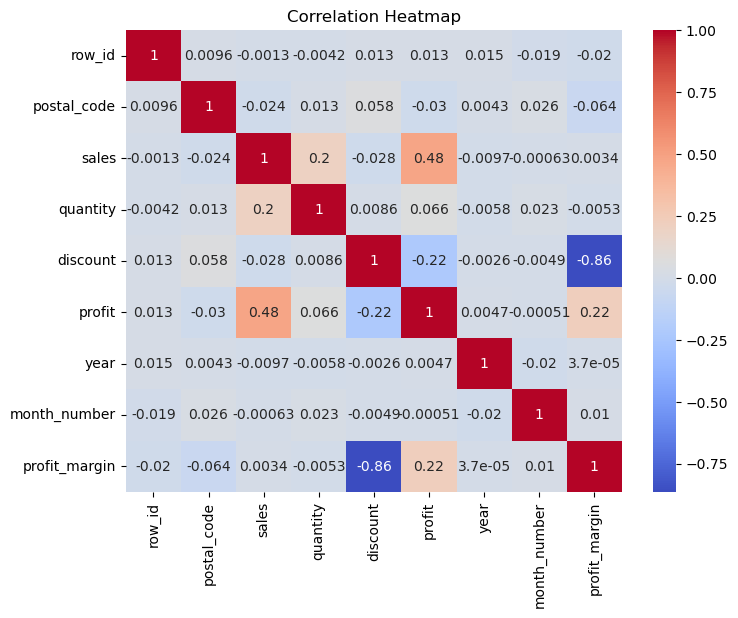

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../visuals/correlational_analysis/correlational_heatmap.png",
            dpi = 300,
            bbox_inches = "tight")
plt.show()

### Observations and Insights

1. Profits v/s Sales
- Higher the sales, more are the profits earned by the business

2. Profit Margin v/s Discount
- Higher discounts lead to lower profit margins.
- Discounts need to be timed well according to the season.
- They need to be optimized as well to balance customer attraction and profits.


## Final Summary

- Sales have shown steady growth over time, with the strongest performance observed in 2017.
- Sales and profits consistently peak during year-end months, indicating strong seasonal demand.
- Some high-selling products generate losses, highlighting the need for pricing and cost optimization.
- The Consumer segment is the largest contributor to both sales and profits.
- The West and East regions are the strongest markets, while the Central and South regions have growth potential.
- Most customers are concentrated in major metropolitan cities, though smaller cities present expansion opportunities.
- Excessive discounting negatively impacts profit margins, thus needs to be optimized.

**_Future growth can be driven by optimizing discounts, improving profitability of loss-making products, and strengthening presence in underperforming regions._**